In [1]:
import sys
sys.path.insert(0, '/home/alexis/Greendc')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

ROOT = Path('/home/alexis/Greendc')
RAW = ROOT / 'carbon_model' / 'data' / 'raw'
PROCESSED = ROOT / 'carbon_model' / 'data' / 'processed'
OUTPUTS = ROOT / 'carbon_model' / 'data' / 'outputs'
YEAR = 2023
print(f'Pipeline GreenDC {YEAR} \u2014 Approche Graphe + Zones')

Pipeline GreenDC 2023 — Approche Graphe + Zones


# \u00c9tape 1 : Donn\u00e9es eco2mix 2023

In [2]:
from carbon_model.downloaders.download_rte import RTEDownloader
loader = RTEDownloader(dest_dir=RAW / 'rte')
rte_path = sorted((RAW / 'rte').glob('eco2mix_2023*'))[0]
rte_raw = loader.load_eco2mix_csv(rte_path)
rte_h = rte_raw.select_dtypes(include='number').resample('h').mean().fillna(0)
if 'Hydro Run-of-river' in rte_h.columns:
    rte_h.rename(columns={'Hydro Run-of-river': 'Hydro'}, inplace=True)
ci_rte = rte_h['co2_rate_gco2_kwh'] if 'co2_rate_gco2_kwh' in rte_h.columns else None
print(f'Eco2mix : {len(rte_h)} timestamps horaires')
print(f'CI RTE moyen : {ci_rte.mean():.1f} gCO2/kWh')
print(f'Consommation moyenne : {rte_h["consumption_mw"].mean():.0f} MW')

2026-03-23 11:47:57.741 | WARNING  | carbon_model.downloaders.download_rte:load_eco2mix_csv:309 - Eco2mix tab terminal détecté : header=40 cols, data=41 cols → correction
2026-03-23 11:47:58.176 | WARNING  | carbon_model.downloaders.download_rte:load_eco2mix_csv:439 - Eco2mix : 17520/35040 lignes vides supprimées (données 2023-01-01 00:00:00 → 2023-12-31 23:45:00, résolution < horaire)
2026-03-23 11:47:58.178 | SUCCESS  | carbon_model.downloaders.download_rte:load_eco2mix_csv:448 - Eco2mix chargé : 17520 timesteps


Eco2mix : 8760 timestamps horaires
CI RTE moyen : 29.7 gCO2/kWh
Consommation moyenne : 49723 MW


# \u00c9tape 2 : R\u00e9seau

In [3]:
import pypsa
from carbon_model.network.network_builder import load_from_osm_csvs, validate_network

snapshots = pd.date_range(f'{YEAR}-01-01', periods=8760, freq='h')
net = load_from_osm_csvs(
    buses_csv=RAW / 'pypsa/buses.csv',
    lines_csv=RAW / 'pypsa/lines.csv',
    links_csv=RAW / 'pypsa/links.csv',
    snapshots=snapshots,
)
print(f'R\u00e9seau : {len(net.buses)} bus, {len(net.lines)} lignes')
print(f'Bus FR : {(net.buses["country"]=="FR").sum()}')

2026-03-23 11:48:00.672 | INFO     | carbon_model.network.network_builder:load_from_osm_csvs:388 - Chargement réseau depuis CSV Zenodo OSM : /home/alexis/Greendc/carbon_model/data/raw/pypsa
2026-03-23 11:48:00.691 | INFO     | carbon_model.network.network_builder:load_from_osm_csvs:401 - Buses retenus : 4393 (FR=1210, voisins=3183)
2026-03-23 11:48:00.851 | INFO     | carbon_model.network.network_builder:load_from_osm_csvs:435 - Lignes retenues : 5888
2026-03-23 11:48:00.963 | INFO     | carbon_model.network.network_builder:load_from_osm_csvs:505 - Liens HVDC retenus : 0
2026-03-23 11:48:00.964 | SUCCESS  | carbon_model.network.network_builder:load_from_osm_csvs:507 - Réseau OSM/Zenodo : 4393 bus, 5888 lignes AC, 0 liens HVDC


Réseau : 4393 bus, 5888 lignes
Bus FR : 1210


# \u00c9tape 3 : Centrales

In [4]:
import geopandas as gpd
from carbon_model.plants.plant_integrator import (
    load_plants_registry, plants_to_geodataframe,
    snap_plants_to_network, add_generators_to_network
)

plants_df = load_plants_registry(RAW / 'plants/plants_france_clean.csv')
plants_gdf = plants_to_geodataframe(plants_df)
buses_gdf = gpd.GeoDataFrame(
    net.buses, geometry=gpd.points_from_xy(net.buses['x'], net.buses['y']), crs='EPSG:4326'
)
plants_gdf = snap_plants_to_network(plants_gdf, buses_gdf, max_distance_km=100)
add_generators_to_network(net, plants_gdf)
print(f'G\u00e9n\u00e9rateurs : {len(net.generators)}, Capacit\u00e9 : {net.generators.p_nom.sum()/1e3:.1f} GW')

print('\n\u2500\u2500 Carriers \u2500\u2500')
for carrier, group in net.generators.groupby('carrier'):
    print(f'  {carrier:15s} : {len(group):>5d} gens, {group.p_nom.sum():>8.0f} MW')

2026-03-23 11:48:01.069 | INFO     | carbon_model.plants.plant_integrator:load_plants_registry:54 - Registre centrales : 46070 centrales, capacité totale 157.1 GW
tech_normalized
nuclear          62990.000000
hydro            25673.374350
wind             24029.882710
solar            20637.571718
gas              12748.640570
oil               2924.482400
biomass           2556.603699
wind_offshore     2008.200000
coal              1810.719000
storage           1458.254000
other              288.734000
geothermal           1.850000
2026-03-23 11:48:01.313 | INFO     | carbon_model.plants.plant_integrator:snap_plants_to_network:118 - Snapping centrales → réseau :
  Connectées   : 45937/46070 (100%)
  Capacité OK  : 156.3/157.1 GW
  Distance moy : 17.0 km
2026-03-23 11:48:01.319 | WARNING  | carbon_model.plants.plant_integrator:snap_plants_to_network:130 - 2 centrales > 100 MW non connectées :
            name tech_normalized  capacity_mw  dist_to_bus_km
4   Confidentiel             oil

Générateurs : 3115, Capacité : 156.3 GW

── Carriers ──
  biomass         :   442 gens,     2554 MW
  coal            :     6 gens,     1811 MW
  gas             :   364 gens,    12749 MW
  geothermal      :     1 gens,        2 MW
  hydro           :   443 gens,    25453 MW
  nuclear         :    18 gens,    62990 MW
  oil             :   119 gens,     2555 MW
  other           :    30 gens,      289 MW
  solar           :  1043 gens,    20466 MW
  storage         :   318 gens,     1453 MW
  wind            :   325 gens,    24012 MW
  wind_offshore   :     6 gens,     2008 MW


# \u00c9tape 4 : Dispatch

In [5]:
from carbon_model.simulation.dispatch import (
    disaggregate_national_to_nodes, apply_dispatch_to_network,
    disaggregate_load_to_nodes
)

# Mapping eco2mix \u2192 carriers
carrier_col_map = {
    'Nuclear': 'nuclear', 'Wind Onshore': 'wind', 'Solar': 'solar',
    'Hydro': 'hydro', 'Biomass': 'biomass', 'Fossil Gas': 'gas',
    'Fossil Oil': 'oil', 'Fossil Hard Coal': 'coal', 'Hydro Pumped Storage': 'storage',
}
national_prod = pd.DataFrame(index=rte_h.index)
for eco_col, carrier in carrier_col_map.items():
    if eco_col in rte_h.columns:
        national_prod[carrier] = rte_h[eco_col].clip(lower=0).fillna(0)

dispatch_df = disaggregate_national_to_nodes(net, national_prod)
apply_dispatch_to_network(net, dispatch_df, snapshots)

# Consommation
national_conso = rte_h['consumption_mw'].fillna(0)
disaggregate_load_to_nodes(net, national_conso)

# STEP pompage \u2192 loads
step_national = rte_h.get('Hydro Pumped Storage', pd.Series(0, index=rte_h.index))
pompage = step_national.clip(upper=0).abs()
step_gens = net.generators[net.generators['carrier'] == 'storage'].index
if len(step_gens) > 0:
    step_caps = net.generators.loc[step_gens, 'p_nom']
    weights = step_caps / step_caps.sum()
    for gen_id in step_gens:
        bus = net.generators.loc[gen_id, 'bus']
        load_id = f'load_step_{gen_id}'
        if load_id not in net.loads.index:
            net.add('Load', load_id, bus=bus)
        net.loads_t.p_set[load_id] = pompage * weights[gen_id]

prod_h = net.generators_t.p_set.sum(axis=1)
load_h = net.loads_t.p_set.sum(axis=1)
print(f'Production : {prod_h.mean()/1e3:.1f} GW ({prod_h.sum()/1e6:.1f} TWh)')
print(f'Consommation : {load_h.mean()/1e3:.1f} GW ({load_h.sum()/1e6:.1f} TWh)')
print(f'Surplus : {(prod_h - load_h).mean()/1e3:.1f} GW')

2026-03-23 11:49:48.837 | INFO     | carbon_model.simulation.dispatch:disaggregate_national_to_nodes:44 - Désagrégation production nationale → nœuds (méthode: capacity_weighted)
2026-03-23 11:49:49.331 | SUCCESS  | carbon_model.simulation.dispatch:disaggregate_national_to_nodes:86 - Dispatch vectorisé : 8760 timesteps × 3115 générateurs
2026-03-23 11:49:49.362 | INFO     | carbon_model.simulation.dispatch:apply_dispatch_to_network:114 - Dispatch appliqué :
  Production moyenne : 56.2 GW
  Production min     : 35.4 GW
  Production max     : 81.9 GW
2026-03-23 11:50:15.971 | INFO     | carbon_model.simulation.dispatch:disaggregate_load_to_nodes:179 - Consommation ventilée sur 1210 nœuds :
  Consommation moyenne : 49.7 GW


Production : 56.2 GW (492.6 TWh)
Consommation : 50.4 GW (441.3 TWh)
Surplus : 5.9 GW


# \u00c9tape 5 : DC Power Flow

In [6]:
import time

# Corrections r\u00e9seau
transfo_mask = net.lines.index.str.startswith('_transfo_')
net.lines.loc[transfo_mask, 'x'] = 0.1
net.lines.loc[transfo_mask, 's_nom'] = 4000
print(f'Transfos corrig\u00e9s : {transfo_mask.sum()}')

critical_lines = ['way/132920954-225', 'way/132920951-225',
                  'way/183182432-225', 'relation/6694738-225-b']
for lid in critical_lines:
    if lid in net.lines.index:
        net.lines.loc[lid, 'x'] /= 2
print(f'Corridor FR137 : x/2')

# DC-LPF mensuel
t0 = time.time()
for i in range(12):
    start_m = f'{YEAR}-{i+1:02d}-01'
    if i < 11:
        end_m = f'{YEAR}-{i+2:02d}-01'
        month_snaps = net.snapshots[(net.snapshots >= start_m) & (net.snapshots < end_m)]
    else:
        month_snaps = net.snapshots[net.snapshots >= start_m]
    net.lpf(month_snaps)
    print(f'  Mois {i+1:>2}/12 : {len(month_snaps)} snaps \u2014 {time.time()-t0:.0f}s')

flows = net.lines_t.p0
print(f'\n\u2705 DC-LPF : {flows.shape}, flux max={flows.abs().max().max():.0f} MW')

Transfos corrigés : 0
Corridor FR137 : x/2


INFO:pypsa.network.power_flow:Performing linear load-flow on AC sub-network <pypsa.networks.SubNetwork object at 0x701d33a0df70> for snapshot(s) DatetimeIndex(['2023-01-01 00:00:00', '2023-01-01 01:00:00',
               '2023-01-01 02:00:00', '2023-01-01 03:00:00',
               '2023-01-01 04:00:00', '2023-01-01 05:00:00',
               '2023-01-01 06:00:00', '2023-01-01 07:00:00',
               '2023-01-01 08:00:00', '2023-01-01 09:00:00',
               ...
               '2023-01-31 14:00:00', '2023-01-31 15:00:00',
               '2023-01-31 16:00:00', '2023-01-31 17:00:00',
               '2023-01-31 18:00:00', '2023-01-31 19:00:00',
               '2023-01-31 20:00:00', '2023-01-31 21:00:00',
               '2023-01-31 22:00:00', '2023-01-31 23:00:00'],
              dtype='datetime64[us]', name='snapshot', length=744, freq='h')
INFO:pypsa.network.power_flow:Performing linear load-flow on AC sub-network <pypsa.networks.SubNetwork object at 0x701d38462ae0> for snapshot(s) Dat

INFO:pypsa.network.power_flow:Performing linear load-flow on AC sub-network <pypsa.networks.SubNetwork object at 0x701d33a0e510> for snapshot(s) DatetimeIndex(['2023-01-01 00:00:00', '2023-01-01 01:00:00',
               '2023-01-01 02:00:00', '2023-01-01 03:00:00',
               '2023-01-01 04:00:00', '2023-01-01 05:00:00',
               '2023-01-01 06:00:00', '2023-01-01 07:00:00',
               '2023-01-01 08:00:00', '2023-01-01 09:00:00',
               ...
               '2023-01-31 14:00:00', '2023-01-31 15:00:00',
               '2023-01-31 16:00:00', '2023-01-31 17:00:00',
               '2023-01-31 18:00:00', '2023-01-31 19:00:00',
               '2023-01-31 20:00:00', '2023-01-31 21:00:00',
               '2023-01-31 22:00:00', '2023-01-31 23:00:00'],
              dtype='datetime64[us]', name='snapshot', length=744, freq='h')
INFO:pypsa.network.power_flow:Performing linear load-flow on AC sub-network <pypsa.networks.SubNetwork object at 0x701d33a0ed20> for snapshot(s) Dat

INFO:pypsa.network.power_flow:Performing linear load-flow on AC sub-network <pypsa.networks.SubNetwork object at 0x701d33a0f650> for snapshot(s) DatetimeIndex(['2023-01-01 00:00:00', '2023-01-01 01:00:00',
               '2023-01-01 02:00:00', '2023-01-01 03:00:00',
               '2023-01-01 04:00:00', '2023-01-01 05:00:00',
               '2023-01-01 06:00:00', '2023-01-01 07:00:00',
               '2023-01-01 08:00:00', '2023-01-01 09:00:00',
               ...
               '2023-01-31 14:00:00', '2023-01-31 15:00:00',
               '2023-01-31 16:00:00', '2023-01-31 17:00:00',
               '2023-01-31 18:00:00', '2023-01-31 19:00:00',
               '2023-01-31 20:00:00', '2023-01-31 21:00:00',
               '2023-01-31 22:00:00', '2023-01-31 23:00:00'],
              dtype='datetime64[us]', name='snapshot', length=744, freq='h')
INFO:pypsa.network.power_flow:Performing linear load-flow on AC sub-network <pypsa.networks.SubNetwork object at 0x701d33a0c710> for snapshot(s) Dat

INFO:pypsa.network.power_flow:Performing linear load-flow on AC sub-network <pypsa.networks.SubNetwork object at 0x701d33a0d310> for snapshot(s) DatetimeIndex(['2023-01-01 00:00:00', '2023-01-01 01:00:00',
               '2023-01-01 02:00:00', '2023-01-01 03:00:00',
               '2023-01-01 04:00:00', '2023-01-01 05:00:00',
               '2023-01-01 06:00:00', '2023-01-01 07:00:00',
               '2023-01-01 08:00:00', '2023-01-01 09:00:00',
               ...
               '2023-01-31 14:00:00', '2023-01-31 15:00:00',
               '2023-01-31 16:00:00', '2023-01-31 17:00:00',
               '2023-01-31 18:00:00', '2023-01-31 19:00:00',
               '2023-01-31 20:00:00', '2023-01-31 21:00:00',
               '2023-01-31 22:00:00', '2023-01-31 23:00:00'],
              dtype='datetime64[us]', name='snapshot', length=744, freq='h')
INFO:pypsa.network.power_flow:Performing linear load-flow on AC sub-network <pypsa.networks.SubNetwork object at 0x701d33a0f5c0> for snapshot(s) Dat

...

INFO:pypsa.network.power_flow:Performing linear load-flow on AC sub-network <pypsa.networks.SubNetwork object at 0x701d33a0f560> for snapshot(s) DatetimeIndex(['2023-12-01 00:00:00', '2023-12-01 01:00:00',
               '2023-12-01 02:00:00', '2023-12-01 03:00:00',
               '2023-12-01 04:00:00', '2023-12-01 05:00:00',
               '2023-12-01 06:00:00', '2023-12-01 07:00:00',
               '2023-12-01 08:00:00', '2023-12-01 09:00:00',
               ...
               '2023-12-31 14:00:00', '2023-12-31 15:00:00',
               '2023-12-31 16:00:00', '2023-12-31 17:00:00',
               '2023-12-31 18:00:00', '2023-12-31 19:00:00',
               '2023-12-31 20:00:00', '2023-12-31 21:00:00',
               '2023-12-31 22:00:00', '2023-12-31 23:00:00'],
              dtype='datetime64[us]', name='snapshot', length=744, freq='h')
INFO:pypsa.network.power_flow:Performing linear load-flow on AC sub-network <pypsa.networks.SubNetwork object at 0x701d33a0c0b0> for snapshot(s) Dat

INFO:pypsa.network.power_flow:Performing linear load-flow on AC sub-network <pypsa.networks.SubNetwork object at 0x701d33a0fd10> for snapshot(s) DatetimeIndex(['2023-12-01 00:00:00', '2023-12-01 01:00:00',
               '2023-12-01 02:00:00', '2023-12-01 03:00:00',
               '2023-12-01 04:00:00', '2023-12-01 05:00:00',
               '2023-12-01 06:00:00', '2023-12-01 07:00:00',
               '2023-12-01 08:00:00', '2023-12-01 09:00:00',
               ...
               '2023-12-31 14:00:00', '2023-12-31 15:00:00',
               '2023-12-31 16:00:00', '2023-12-31 17:00:00',
               '2023-12-31 18:00:00', '2023-12-31 19:00:00',
               '2023-12-31 20:00:00', '2023-12-31 21:00:00',
               '2023-12-31 22:00:00', '2023-12-31 23:00:00'],
              dtype='datetime64[us]', name='snapshot', length=744, freq='h')
INFO:pypsa.network.power_flow:Performing linear load-flow on AC sub-network <pypsa.networks.SubNetwork object at 0x701d33a0d010> for snapshot(s) Dat

INFO:pypsa.network.power_flow:Performing linear load-flow on AC sub-network <pypsa.networks.SubNetwork object at 0x701d33a0d130> for snapshot(s) DatetimeIndex(['2023-12-01 00:00:00', '2023-12-01 01:00:00',
               '2023-12-01 02:00:00', '2023-12-01 03:00:00',
               '2023-12-01 04:00:00', '2023-12-01 05:00:00',
               '2023-12-01 06:00:00', '2023-12-01 07:00:00',
               '2023-12-01 08:00:00', '2023-12-01 09:00:00',
               ...
               '2023-12-31 14:00:00', '2023-12-31 15:00:00',
               '2023-12-31 16:00:00', '2023-12-31 17:00:00',
               '2023-12-31 18:00:00', '2023-12-31 19:00:00',
               '2023-12-31 20:00:00', '2023-12-31 21:00:00',
               '2023-12-31 22:00:00', '2023-12-31 23:00:00'],
              dtype='datetime64[us]', name='snapshot', length=744, freq='h')
INFO:pypsa.network.power_flow:Performing linear load-flow on AC sub-network <pypsa.networks.SubNetwork object at 0x701d33a0e750> for snapshot(s) Dat

INFO:pypsa.network.power_flow:Performing linear load-flow on AC sub-network <pypsa.networks.SubNetwork object at 0x701d268c7140> for snapshot(s) DatetimeIndex(['2023-12-01 00:00:00', '2023-12-01 01:00:00',
               '2023-12-01 02:00:00', '2023-12-01 03:00:00',
               '2023-12-01 04:00:00', '2023-12-01 05:00:00',
               '2023-12-01 06:00:00', '2023-12-01 07:00:00',
               '2023-12-01 08:00:00', '2023-12-01 09:00:00',
               ...
               '2023-12-31 14:00:00', '2023-12-31 15:00:00',
               '2023-12-31 16:00:00', '2023-12-31 17:00:00',
               '2023-12-31 18:00:00', '2023-12-31 19:00:00',
               '2023-12-31 20:00:00', '2023-12-31 21:00:00',
               '2023-12-31 22:00:00', '2023-12-31 23:00:00'],
              dtype='datetime64[us]', name='snapshot', length=744, freq='h')
INFO:pypsa.network.power_flow:Performing linear load-flow on AC sub-network <pypsa.networks.SubNetwork object at 0x701d268c5bb0> for snapshot(s) Dat

  Mois 12/12 : 744 snaps — 267s

✅ DC-LPF : (8760, 5888), flux max=40539 MW


# \u00c9tape 6 : CI production directe par bus

In [7]:
from carbon_model.plants.emission_factors import EMISSION_FACTORS

ef_map = {'nuclear': 12, 'wind': 11, 'solar': 45, 'hydro': 24,
          'biomass': 230, 'gas': 490, 'oil': 650, 'coal': 820, 'storage': 5,
          'other': 300, 'geothermal': 38, 'wind_offshore': 11}

# CI par bus = \u03a3(gen_production \u00d7 EF) / \u03a3(gen_production)
gen_p_mean = net.generators_t.p_set.mean()
bus_emissions = pd.Series(0.0, index=net.buses.index)
bus_production = pd.Series(0.0, index=net.buses.index)

for gen_id, gen in net.generators.iterrows():
    p = max(gen_p_mean.get(gen_id, 0), 0)
    ef = ef_map.get(gen.carrier, 300)
    bus_emissions[gen.bus] += p * ef
    bus_production[gen.bus] += p

ci_bus_direct = (bus_emissions / bus_production.replace(0, np.nan)).fillna(0)

print(f'Bus avec production : {(bus_production > 0).sum()}')
print(f'CI direct mean (bus actifs) : {ci_bus_direct[ci_bus_direct > 0].mean():.1f} gCO2/kWh')
print(f'CI direct median : {ci_bus_direct[ci_bus_direct > 0].median():.1f}')

# CI nationale directe (v\u00e9rification)
ci_nat_direct = bus_emissions.sum() / bus_production.sum()
print(f'\nCI nationale directe : {ci_nat_direct:.1f} gCO2/kWh')
print(f'CI RTE r\u00e9f\u00e9rence : {ci_rte.mean():.1f} gCO2/kWh')
print(f'Ratio lifecycle/RTE : {ci_nat_direct / ci_rte.mean():.2f}')

Bus avec production : 1090
CI direct mean (bus actifs) : 115.1 gCO2/kWh
CI direct median : 45.0

CI nationale directe : 50.2 gCO2/kWh
CI RTE référence : 29.7 gCO2/kWh
Ratio lifecycle/RTE : 1.69


# \u00c9tape 7 : Partition en zones

── 4 zones ──
  Zone 0 : CI=49.3 gCO2/kWh, 826 bus (409 FR), prod=15.9 GW
  Zone 1 : CI=45.1 gCO2/kWh, 877 bus (429 FR), prod=21.0 GW
  Zone 2 : CI=84.4 gCO2/kWh, 1531 bus (165 FR), prod=5.6 GW
  Zone 3 : CI=45.3 gCO2/kWh, 1159 bus (207 FR), prod=13.8 GW


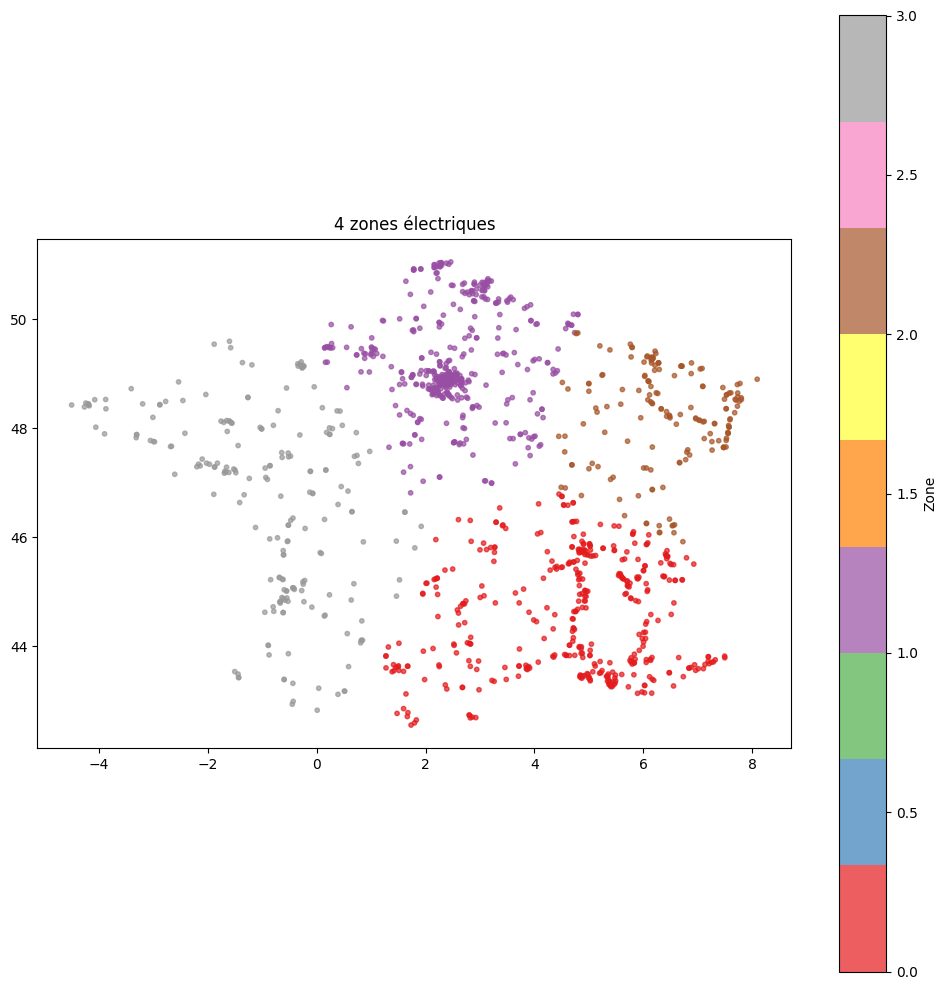

In [8]:
from sklearn.cluster import KMeans

# Clustering sur les bus avec g\u00e9n\u00e9rateurs (comme pipeline_v2 cell 74)
n_zones = 4
gen_buses = net.generators.bus.unique()
gen_coords = np.column_stack([
    net.buses.loc[gen_buses, 'y'].values,
    net.buses.loc[gen_buses, 'x'].values
])
km = KMeans(n_clusters=n_zones, random_state=42, n_init=10)
km.fit(gen_coords)

# Assigner tous les bus \u00e0 une zone
all_coords = np.column_stack([net.buses['y'].values, net.buses['x'].values])
net.buses['zone'] = km.predict(all_coords)

# CI zonal pond\u00e9r\u00e9 par production
zone_ci = {}
for z in range(n_zones):
    mask = net.buses['zone'] == z
    buses_z = net.buses.index[mask]
    prod_z = bus_production[buses_z]
    em_z = bus_emissions[buses_z]
    ci_z = em_z.sum() / prod_z.sum() if prod_z.sum() > 0 else ci_nat_direct
    zone_ci[z] = ci_z

print(f'\u2500\u2500 {n_zones} zones \u2500\u2500')
for z in range(n_zones):
    mask = net.buses['zone'] == z
    n_bus = mask.sum()
    n_fr = ((net.buses['zone'] == z) & (net.buses['country'] == 'FR')).sum()
    prod_gw = bus_production[net.buses.index[mask]].sum() / 1e3
    print(f'  Zone {z} : CI={zone_ci[z]:.1f} gCO2/kWh, {n_bus} bus ({n_fr} FR), prod={prod_gw:.1f} GW')

# Visualisation zones
fig, ax = plt.subplots(figsize=(10, 10))
fr_mask = net.buses['country'] == 'FR'
scatter = ax.scatter(
    net.buses.loc[fr_mask, 'x'], net.buses.loc[fr_mask, 'y'],
    c=net.buses.loc[fr_mask, 'zone'], cmap='Set1', s=10, alpha=0.7
)
ax.set_title(f'{n_zones} zones \u00e9lectriques')
ax.set_aspect('equal')
plt.colorbar(scatter, label='Zone')
plt.tight_layout()
plt.show()

# \u00c9tape 8 : Lissage CI \u2014 Log \u03b1 + zones

In [9]:
# CI final = exp(\u03b1 \u00d7 log(CI_local) + (1-\u03b1) \u00d7 log(CI_zone))
# \u03b1 = 0.1 \u2192 10% signal local, 90% zonal
alpha = 0.1

ci_final_bus = pd.Series(0.0, index=net.buses.index)
for bus_id in net.buses.index:
    z = net.buses.loc[bus_id, 'zone']
    ci_local = max(ci_bus_direct[bus_id], 1.0)  # floor 1 pour log
    ci_z = max(zone_ci[z], 1.0)
    ci_final_bus[bus_id] = np.exp(alpha * np.log(ci_local) + (1 - alpha) * np.log(ci_z))

# Stats sur bus FR avec load
fr_load_buses = set(net.loads.bus.values)
ci_fr = ci_final_bus[[b for b in ci_final_bus.index if b in fr_load_buses]]

print(f'\u2500\u2500 CI apr\u00e8s lissage (\u03b1={alpha}, {n_zones} zones) \u2500\u2500')
print(f'CI mean  : {ci_fr.mean():.1f} gCO2/kWh')
print(f'CI median: {ci_fr.median():.1f}')
print(f'CI p10   : {ci_fr.quantile(0.1):.1f}')
print(f'CI p90   : {ci_fr.quantile(0.9):.1f}')
print(f'CI max   : {ci_fr.max():.1f}')
print(f'CI min   : {ci_fr.min():.1f}')

# CI nationale load-weighted
national_conso_bus = {}
for lid in net.loads.index:
    bus = net.loads.loc[lid, 'bus']
    p = net.loads_t.p_set[lid].mean()
    national_conso_bus[bus] = national_conso_bus.get(bus, 0) + p

num = sum(ci_final_bus[b] * p for b, p in national_conso_bus.items())
den = sum(national_conso_bus.values())
ci_national_lw = num / den
print(f'\nCI nationale load-weighted : {ci_national_lw:.1f} gCO2/kWh')
print(f'CI RTE : {ci_rte.mean():.1f}')
print(f'Ratio : {ci_national_lw / ci_rte.mean():.2f}')

── CI après lissage (α=0.1, 4 zones) ──
CI mean  : 51.5 gCO2/kWh
CI median: 48.5
CI p10   : 39.3
CI p90   : 75.2
CI max   : 101.4
CI min   : 30.8

CI nationale load-weighted : 51.5 gCO2/kWh
CI RTE : 29.7
Ratio : 1.74


# \u00c9tape 9 : Validation \u2014 sites de r\u00e9f\u00e9rence

In [10]:
# Sites de r\u00e9f\u00e9rence pour validation qualitative
test_sites = [
    ('Gravelines (nuc)',      51.015,  2.107, 'nuc'),
    ('Flamanville (nuc)',     49.538, -1.881, 'nuc'),
    ('Tricastin (nuc)',       44.333,  4.733, 'nuc'),
    ('Cattenom (nuc)',        49.406,  6.219, 'nuc'),
    ('Martigues (gaz)',       43.405,  5.054, 'gaz'),
    ('Bouchain (gaz)',        50.286,  3.315, 'gaz'),
    ('Montoir (gaz)',         47.333, -2.150, 'gaz'),
    ('Cordemais (charbon)',   47.267, -1.883, 'gaz'),
    ('Paris',                 48.857,  2.352, 'ville'),
    ('Lyon',                  45.764,  4.836, 'ville'),
    ('Marseille',             43.297,  5.381, 'ville'),
    ('Toulouse',              43.604,  1.444, 'ville'),
    ('Nantes',                47.218, -1.554, 'ville'),
    ('Strasbourg',            48.573,  7.752, 'ville'),
    ('Bordeaux',              44.838, -0.579, 'ville'),
    ('Lille',                 50.630,  3.057, 'ville'),
    ('Beauce (\u00e9olien)',       48.150,  1.500, 'enr'),
    ('Landes (solaire)',      43.890, -0.500, 'enr'),
]

bus_lats = net.buses['y'].values
bus_lons = net.buses['x'].values

def find_nearest_bus(lat, lon):
    dlat = np.radians(bus_lats - lat)
    dlon = np.radians(bus_lons - lon)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat))*np.cos(np.radians(bus_lats))*np.sin(dlon/2)**2
    dist = 6371 * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    idx = np.argmin(dist)
    return net.buses.index[idx], dist[idx]

print(f'{"Site":28s} | {"Type":>6s} | {"CI local":>9s} | {"CI zone":>8s} | {"CI final":>9s} | {"Zone":>4s}')
print('\u2500' * 80)
prev_type = None
for name, lat, lon, stype in test_sites:
    if stype != prev_type and prev_type is not None:
        print('\u2500' * 80)
    prev_type = stype
    bus_id, dist = find_nearest_bus(lat, lon)
    z = net.buses.loc[bus_id, 'zone']
    ci_local = ci_bus_direct[bus_id]
    ci_z = zone_ci[z]
    ci_f = ci_final_bus[bus_id]
    print(f'{name:28s} | {stype:>6s} | {ci_local:>8.1f} | {ci_z:>7.1f} | {ci_f:>8.1f} | {z:>4d}')

# Plausibilit\u00e9
print(f'\n\u2500\u2500 Plausibilit\u00e9 \u2500\u2500')
expected = {'nuc': (10, 40), 'gaz': (50, 200), 'ville': (30, 80), 'enr': (10, 50)}
ok = 0
total = 0
for name, lat, lon, stype in test_sites:
    bus_id, _ = find_nearest_bus(lat, lon)
    ci_f = ci_final_bus[bus_id]
    lo, hi = expected.get(stype, (0, 500))
    if lo <= ci_f <= hi:
        ok += 1
    total += 1
print(f'  Sites plausibles : {ok}/{total} ({100*ok/total:.0f}%)')

Site                         |   Type |  CI local |  CI zone |  CI final | Zone
────────────────────────────────────────────────────────────────────────────────
Gravelines (nuc)             |    nuc |     12.0 |    45.1 |     39.5 |    1
Flamanville (nuc)            |    nuc |     12.4 |    45.3 |     39.7 |    3
Tricastin (nuc)              |    nuc |     13.3 |    49.3 |     43.2 |    0
Cattenom (nuc)               |    nuc |     12.0 |    84.4 |     69.5 |    2
────────────────────────────────────────────────────────────────────────────────
Martigues (gaz)              |    gaz |    488.6 |    49.3 |     62.0 |    0
Bouchain (gaz)               |    gaz |    459.0 |    45.1 |     56.8 |    1
Montoir (gaz)                |    gaz |    484.7 |    45.3 |     57.4 |    3
Cordemais (charbon)          |    gaz |     15.2 |    45.3 |     40.6 |    3
────────────────────────────────────────────────────────────────────────────────
Paris                        |  ville |      0.0 |    45.1 | 

# \u00c9tape 10 : Visualisation carte

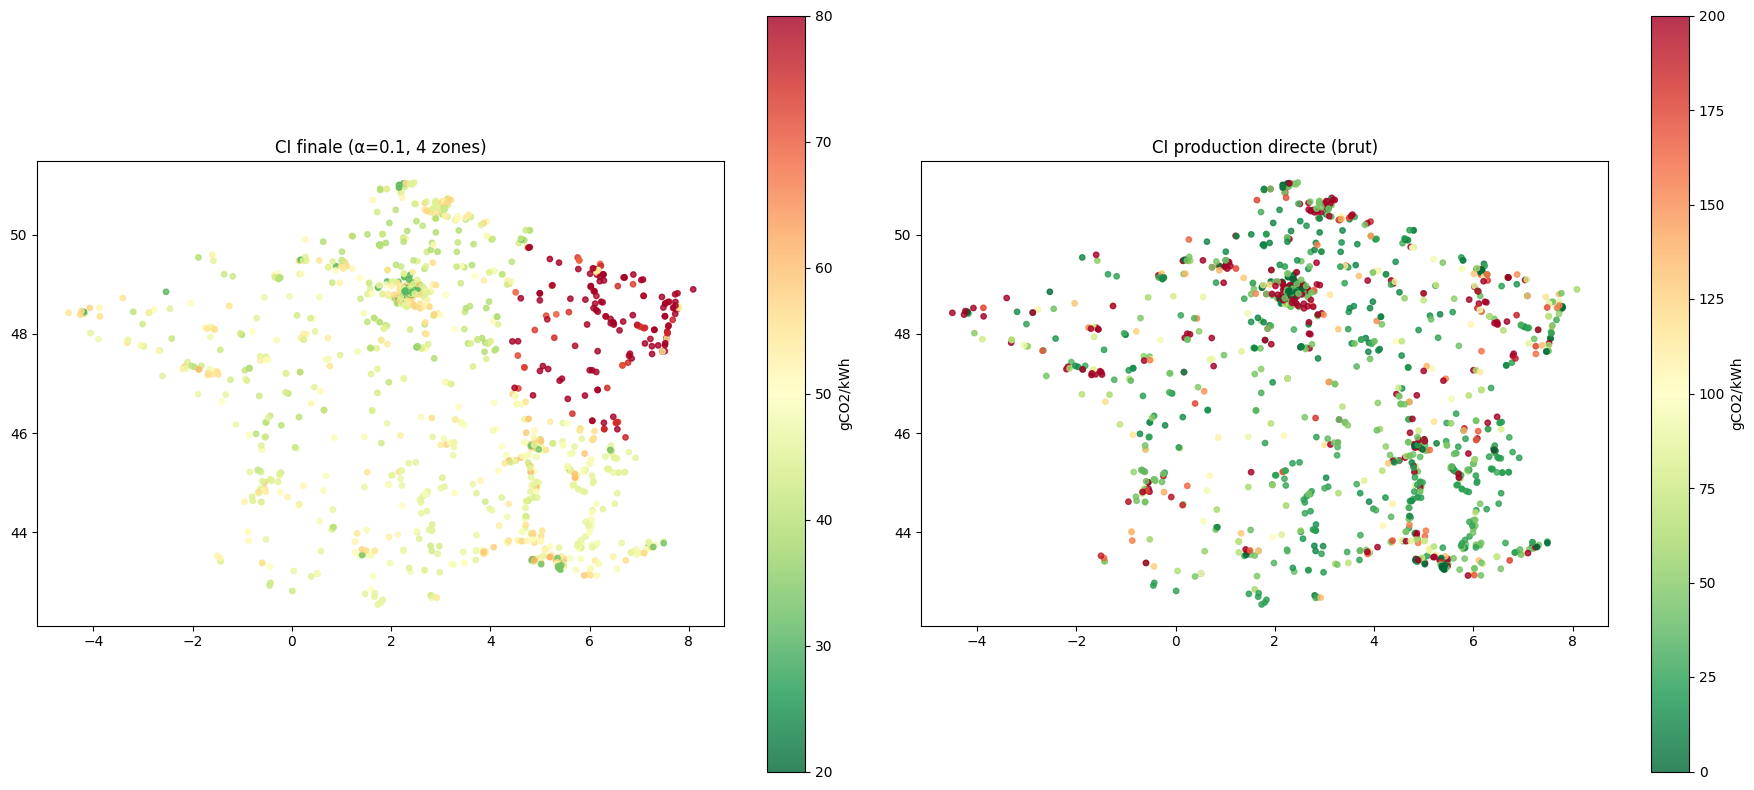

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

fr_mask = net.buses['country'] == 'FR'
fr_buses = net.buses[fr_mask]

# Carte CI final
ax = axes[0]
scatter = ax.scatter(
    fr_buses['x'], fr_buses['y'],
    c=ci_final_bus[fr_buses.index], cmap='RdYlGn_r',
    s=15, alpha=0.8, vmin=20, vmax=80
)
ax.set_title(f'CI finale (\u03b1={alpha}, {n_zones} zones)')
ax.set_aspect('equal')
plt.colorbar(scatter, ax=ax, label='gCO2/kWh')

# Carte CI brut
ax = axes[1]
ci_brut_clipped = ci_bus_direct[fr_buses.index].clip(0, 200)
scatter2 = ax.scatter(
    fr_buses['x'], fr_buses['y'],
    c=ci_brut_clipped, cmap='RdYlGn_r',
    s=15, alpha=0.8, vmin=0, vmax=200
)
ax.set_title('CI production directe (brut)')
ax.set_aspect('equal')
plt.colorbar(scatter2, ax=ax, label='gCO2/kWh')

plt.tight_layout()
plt.show()

# Bilan

In [12]:
print('='*60)
print(f'  BILAN PIPELINE 2023 \u2014 Graphe + Zones')
print('='*60)
print(f'  R\u00e9seau        : {len(net.buses)} bus, {len(net.lines)} lignes')
print(f'  G\u00e9n\u00e9rateurs   : {len(net.generators)}, {net.generators.p_nom.sum()/1e3:.1f} GW')
print(f'  Production    : {prod_h.sum()/1e6:.1f} TWh')
print(f'  Consommation  : {load_h.sum()/1e6:.1f} TWh')
print(f'  Zones         : {n_zones}')
print(f'  Alpha         : {alpha}')
print(f'  CI nationale  : {ci_national_lw:.1f} gCO2/kWh (load-weighted)')
print(f'  CI RTE        : {ci_rte.mean():.1f} gCO2/kWh')
print(f'  Ratio         : {ci_national_lw / ci_rte.mean():.2f}')
for z in range(n_zones):
    print(f'  Zone {z} CI     : {zone_ci[z]:.1f} gCO2/kWh')
print('='*60)

  BILAN PIPELINE 2023 — Graphe + Zones
  Réseau        : 4393 bus, 5888 lignes
  Générateurs   : 3115, 156.3 GW
  Production    : 492.6 TWh
  Consommation  : 441.3 TWh
  Zones         : 4
  Alpha         : 0.1
  CI nationale  : 51.5 gCO2/kWh (load-weighted)
  CI RTE        : 29.7 gCO2/kWh
  Ratio         : 1.74
  Zone 0 CI     : 49.3 gCO2/kWh
  Zone 1 CI     : 45.1 gCO2/kWh
  Zone 2 CI     : 84.4 gCO2/kWh
  Zone 3 CI     : 45.3 gCO2/kWh
